#### Ablation analaysis:
(1) model ablation   
|model         |miou(%)|oa(%)    |kappa  |precision(%)|recall(%)|note|
|----          |----   |----     |----   |------      |----     |----|      
|1-branch      |93.97  |98.62    |0.9352 |97.60%      |96.08%   |    |    
|2-branch      |94.56  |98.75    |0.9418 |97.81%      |96.52%   |    |     
|3-branch      |94.84  |98.85    |0.9449 |97.98%      |96.63%   |    |     
|3-branch+CAFM |95.16  |98.91    |0.9486 |98.10%      |96.86%   |    |         

(2) data ablation     
|data       |miou(%) |oa(%)    |kappa   |precision(%)|recall(%)|note|   
|----       |----    |----     |----    |----        |----     |----|   
|without dem|94.00   |98.69    |0.9339  |97.85%      |95.78%   |    |    
|without ir |92.47   |98.41    |0.9160  |97.19%      |94.91%   |    |    
|without rgb|94.21   |98.68    |0.9376  |97.91%      |96.01%   |    |     

In [1]:
import glob
import torch
import numpy as np
import pandas as pd
import rasterio as rio
from notebooks import config
from utils.imgShow import imsShow
from utils.img2patch import img2patch
from utils.metrics import metrics_segm
from model import unet, u2net, u2net_timm


/home/xin/miniconda3/envs/glanet/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
dir_result = 'data/result/u3net_cross_fusion/'
# dir_result = 'data/result/ablation_module/u3net_timm/'
# dir_result = 'data/result/ablation_data/u3net_timm_remove_rgb/'
paths_val_result = sorted(glob.glob(dir_result + '*.tif'))
print(len(config.paths_scene_val))  


13


In [3]:
## read data
scenes, results, truths = [], [], []
for path_scene, path_result, path_truth in zip(paths_val_scene, paths_val_result,  paths_val_truth):
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()
        scene_arr = scene_arr.transpose((1, 2, 0))   ## (H,W,C)
        scenes.append(scene_arr)
    with rio.open(path_result) as result_rio:
        result_arr = result_rio.read()[0]
        results.append(result_arr)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read()[0]            ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)


In [4]:
metrics_scenes = {}
for i, (result_arr, truth_arr) in enumerate(zip(results, truths)):
    metrics_sg = metrics_segm(cla_map=result_arr, truth_map=truth_arr, 
                              class_labels=[0, 1], mean_mode=True)
    metrics = {'miou': metrics_sg.iou['labels_mean'], 
                'oa': metrics_sg.oa,
                'kappa': metrics_sg.kappa,
                'f1_score': metrics_sg.f1_score['labels_mean'],
                'precision': metrics_sg.precision['labels_mean'],
                'recall': metrics_sg.recall['labels_mean']}
    metrics_scenes[paths_val_truth[i].split('/')[-1].split('.')[0]] = metrics
len(metrics_scenes)  


13

In [5]:
df_metrics_scenes = pd.DataFrame.from_dict(metrics_scenes, orient='index')
df_metrics_scenes.loc['mean'] = df_metrics_scenes.mean(axis=0)
# weighted_avg = (df_metrics_scenes[['oa', 'f1_score', 'miou']].mul(df_metrics_scenes['weight'], axis=0).sum())
# df_metrics_scenes.loc['mean_weighted'] = weighted_avg
# df_metrics_scenes  
df_metrics_scenes.to_csv(dir_result + 'metrics_scenes.csv', index=True)   
df_metrics_scenes  


,miou,oa,kappa,f1_score,precision,recall
l5_scene_01,0.927978,0.981017,0.923899,0.961944,0.951245,0.973453
l5_scene_06,0.918276,0.980850,0.912747,0.956374,0.956502,0.956246
l5_scene_11,0.987541,0.993785,0.987462,0.993731,0.993591,0.993876
l7_scene_03,0.963953,0.981690,0.963294,0.981645,0.982314,0.981227
l7_scene_08,0.971105,0.986451,0.970649,0.985324,0.985298,0.985351
l7_scene_13,0.960728,0.992517,0.959436,0.979716,0.992111,0.968101
l8_scene_05,0.897633,0.992122,0.886935,0.943450,0.986401,0.907966
l8_scene_10,0.975566,0.990930,0.975182,0.987591,0.987373,0.987809
l9_scene_02,0.977494,0.997527,0.977033,0.988517,0.995514,0.981741
l9_scene_07,0.888279,0.979742,0.876890,0.938439,0.951330,0.926439


scene: l9_scene_07.tif, miou: 0.8883


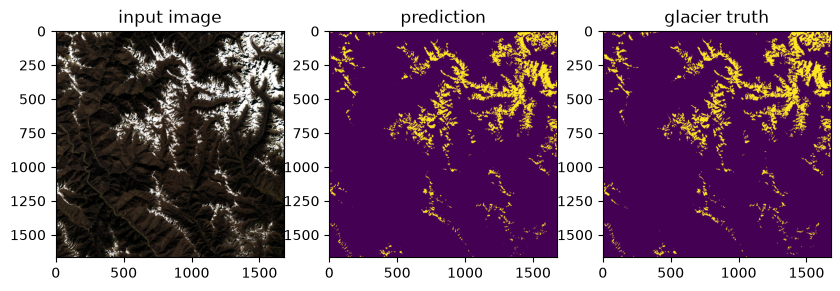

In [6]:
### show the results
i = 9
print(f'scene: {paths_val_scene[i].split("/")[-1]}, miou: {df_metrics_scenes.iloc[i]["miou"]:.4f}')
imsShow([scenes[i], results[i], truths[i]], 
        clip_list=[5, 0, 0], 
        img_name_list = ['input image', 'prediction', 'glacier truth'],
        figsize=(10, 3))
